# Comparing Linear Regression Models On ___Iris DataSet___

##### Importing Initially Required Libraries

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
import numpy as np

## The OLS Algorithm

In [2]:
# OLS Method
def ols(x_train, y_train):
     x = np.matrix(x_train)
     y = np.matrix(y_train)
     b = np.linalg.inv(x.T @ x) @ x.T @ y
     return b
     
def ols_model(x_train, x_test, y_train):
     b = ols(x_train, y_train)
     y_pred = x_test @ b
     return y_pred

## The Batch Gradient Descent Algorithm

In [3]:
def batch_gd(x_train, y_train, iter = 10, n=0.01):
     x = np.matrix(x_train)
     y = np.matrix(y_train)
     b = np.matrix(np.zeros(x.shape[1]).reshape(-1, 1))
     for i in range(iter):
          y_pred = x @ b
          error = y_pred - y
          grad = (2/y.shape[0]) * x.T @ error
          b -= n * grad
     return b

def batch_gd_model(x_train, x_test, y_train, iter = 10, n=0.01):
     b = batch_gd(x_train, y_train, iter, n)
     y_pred = x_test @ b
     return y_pred

## The Main Working Program

Conversion of IRIS DataSet into a DataFrame

In [4]:
iris = load_iris()
iris_data = pd.DataFrame(columns=iris.feature_names)# type: ignore
iris_data[iris_data.columns] = iris.data# type: ignore

iris_data['target'] = iris.target#type:ignore

#### Separating Input and Output Columns
* Added a New Column of ones on the left most for intercept

In [5]:
x=iris_data.drop(columns='target')
x.insert(loc=0, column='intercept', value=1)

y=iris_data['target']

## Training Models

##### Data Splitting

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.3)

### Custom OLS Model

In [13]:
y_pred = ols_model(np.asarray(x_train), np.asarray(x_test), np.asarray(y_train).reshape(-1,1))
y_pred_ = (np.asarray(y_pred).reshape(1,y_pred.shape[0]))[0]

### Custom Batch Gradient Descent Model

In [14]:
y_pred_gd = batch_gd_model(np.asarray(x_train), np.asarray(x_test), np.asarray(y_train).reshape(-1,1), iter=10000)
y_pred__ = (np.asarray(y_pred_gd).reshape(1,y_pred.shape[0]))[0]

### Built-in Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

y_pred2=model.predict(x_test)

##### DataFrame of Outputs

In [16]:
y_dict={
     'y':y_test,
     'y_pred_':y_pred_,
     'y_pred__':y_pred__, 
     'y_pred2':y_pred2
}

out = pd.DataFrame(y_dict, columns=['y','y_pred_','y_pred__','y_pred2'])
print(out)

     y   y_pred_  y_pred__   y_pred2
3    0  0.002886 -0.000256  0.002886
131  2  1.817381  1.831914  1.817381
52   1  1.313010  1.318552  1.313010
123  2  1.582174  1.580073  1.582174
44   0  0.144189  0.147119  0.144189
128  2  1.902314  1.900892  1.902314
111  2  1.715057  1.713777  1.715057
81   1  0.898222  0.894183  0.898222
24   0  0.048667  0.049585  0.048667
7    0 -0.042173 -0.041781 -0.042173
19   0  0.002724  0.005228  0.002724
59   1  1.221226  1.215058  1.221226
78   1  1.323722  1.323096  1.323722
64   1  1.056699  1.053316  1.056699
5    0  0.078029  0.082136  0.078029
100  2  2.237838  2.237039  2.237838
142  2  1.729708  1.725404  1.729708
101  2  1.729708  1.725404  1.729708
145  2  1.931315  1.929285  1.931315
79   1  0.837066  0.834461  0.837066
50   1  1.196224  1.203045  1.196224
149  2  1.642606  1.641542  1.642606
51   1  1.278663  1.281571  1.278663
2    0 -0.046111 -0.048864 -0.046111
120  2  1.999092  2.000800  1.999092
95   1  1.087267  1.087793  1.087267
5

## Mathematical Comparison Of Models

In [17]:
from sklearn.metrics import mean_squared_error, r2_score, precision_score

print(f'My OLS model: MSE={mean_squared_error(y_test, np.asarray(y_pred_))}, r2_score={r2_score(y_test, np.asarray(y_pred_))}')
print(f'My Batch_GD model: MSE={mean_squared_error(y_test, np.asarray(y_pred__))}, r2_score={r2_score(y_test, np.asarray(y_pred__))}')
print(f'His model: MSE={mean_squared_error(y_test, np.asarray(y_pred2))}, r2_score={r2_score(y_test, np.asarray(y_pred2))}')

My OLS model: MSE=0.04048041025724748, r2_score=0.9416147928982007
My Batch_GD model: MSE=0.040564656889760714, r2_score=0.9414932833320759
His model: MSE=0.040480410257249966, r2_score=0.9416147928981972


## Visual Comparison Of Models

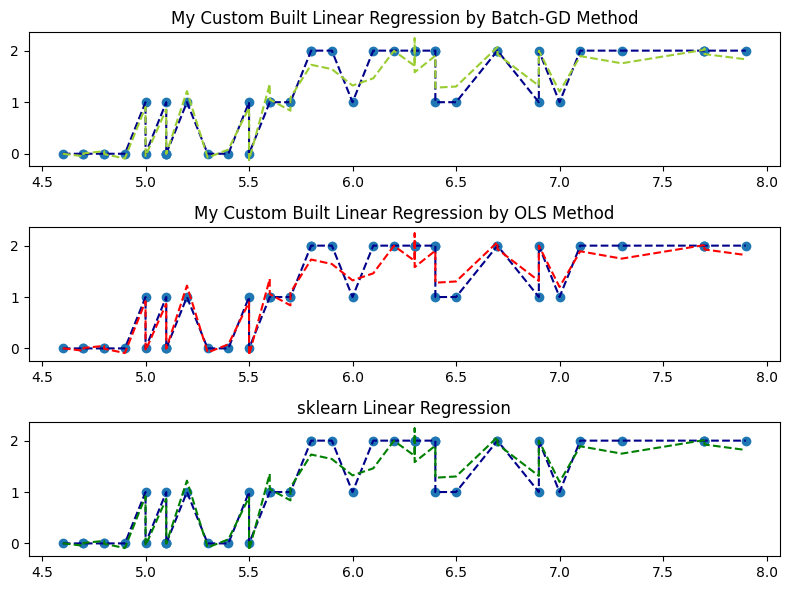

In [18]:
import matplotlib.pyplot as plt

sorted_idx = x_test['sepal length (cm)'].argsort()

fig, ax = plt.subplots(3, 1, figsize=(8, 6))

ax[0].scatter(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx])
ax[0].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx], linestyle='--', color='darkblue')
ax[0].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_pred__[sorted_idx], color='yellowgreen', linestyle='dashed')
ax[0].set_title('My Custom Built Linear Regression by Batch-GD Method')

ax[1].scatter(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx])
ax[1].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx], linestyle='--', color='darkblue')
ax[1].plot(x_test['sepal length (cm)'].iloc[sorted_idx],y_pred_[sorted_idx] , color='red', linestyle='dashed')
ax[1].set_title('My Custom Built Linear Regression by OLS Method')

ax[2].scatter(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx])
ax[2].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx], linestyle='--', color='darkblue')
ax[2].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_pred2[sorted_idx], color='green', linestyle="dashed")
ax[2].set_title('sklearn Linear Regression')

plt.tight_layout()
plt.show()